In [2]:
import pandas as pd
df=pd.read_csv(r"C:\Users\pc\Downloads\archive (5)\netflix_titles.csv")
df
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
## datatypes of each columns
df.head(10)
df.tail()
df.info()
df.dtypes
df.describe(include="all")
df.nunique()
df["date_added"] = pd.to_datetime(
    df["date_added"].astype(str).str.strip(),
    format="mixed",
    errors="coerce"
)
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object    

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,NaN,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,NaN,NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,NaN,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-17 05:59:08.436967168,2014.180198,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-06 00:00:00,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-02 00:00:00,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-19 00:00:00,2019.000000,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-25 00:00:00,2021.000000,NaN,NaN,NaN,NaN


In [51]:
#checking miising values
df.isnull()
df.isnull().sum()
df[df["date_added"].isnull()]
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")
df["duration"] = df["duration"].fillna("Missing")
df["date_added"] = df["date_added"].fillna("missing_date")
df.describe(include="all")
df.isnull().sum()



show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
description        0
types           8807
dtype: int64

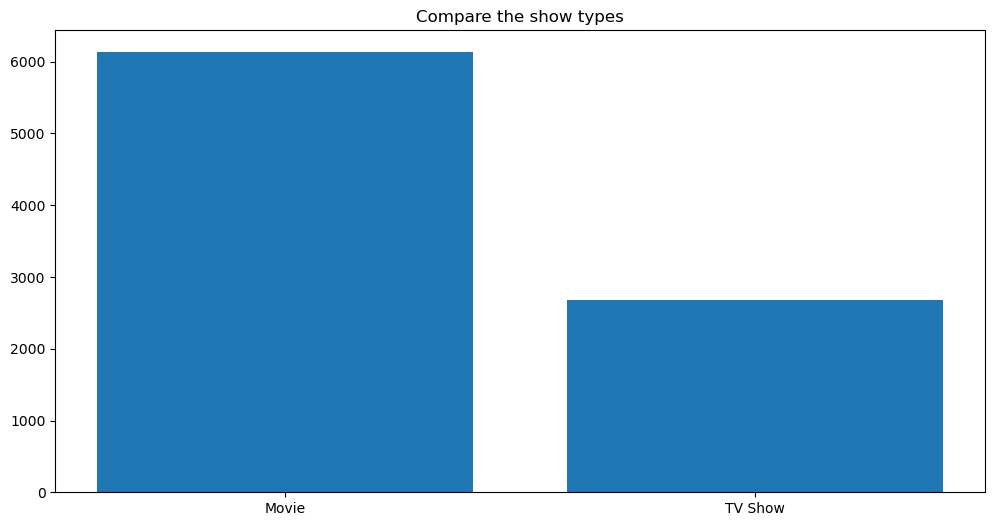

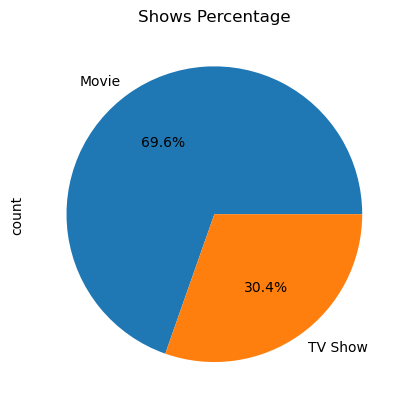

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [25]:
#compare the  show types
types=df["type"].value_counts()
plt.figure(figsize=(12,6))
plt.bar(types.index,
        types.values)
plt.title("Compare the show types")
plt.show()
#show percentage
df["type"].value_counts(normalize=True)*100
df["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%")
plt.title("Shows Percentage")
plt.show()
types

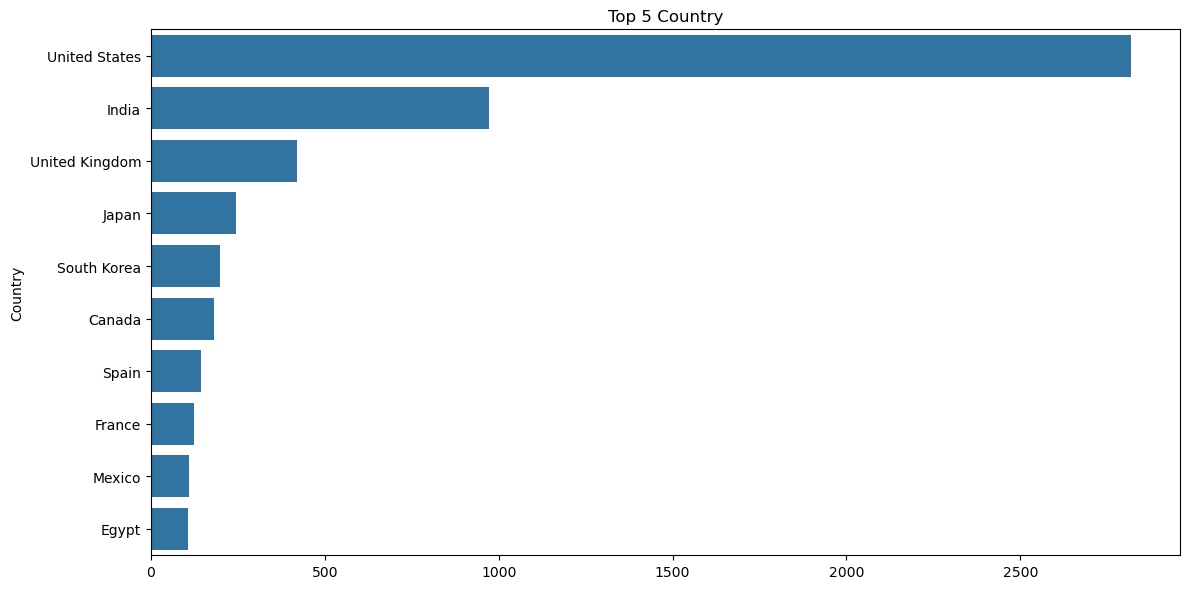

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [24]:
#Top 10 country
top_10_country=(df["country"].dropna().str.split(" ,").explode())
Top_10=top_10_country.value_counts().head(10)
Top_10
plt.figure(figsize=(12,6))
sns.barplot(x=Top_10.values,
        y=Top_10.index)
plt.title("Top 5 Country")
plt.ylabel("Country")
plt.tight_layout()
plt.show()
Top_10

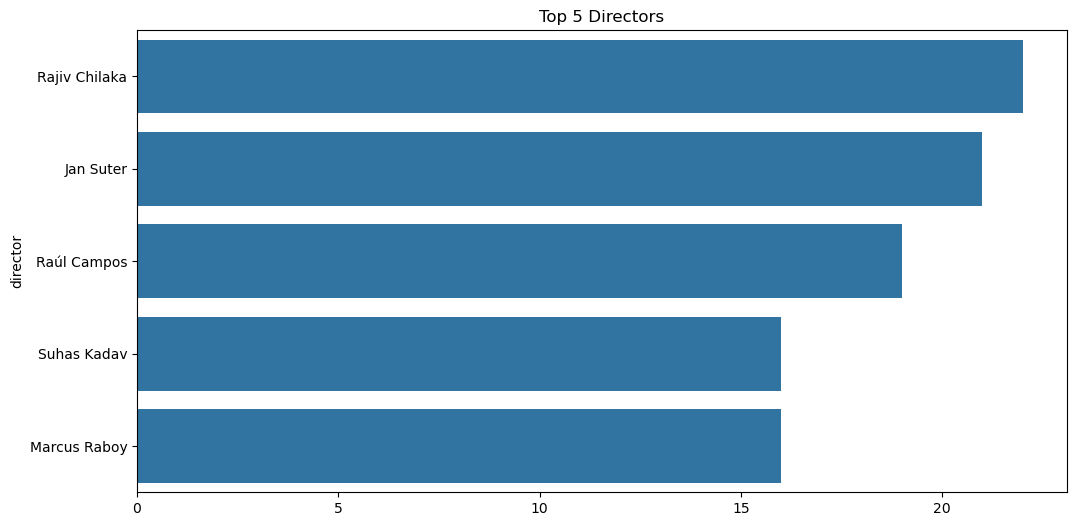

director
Rajiv Chilaka    22
Jan Suter        21
Raúl Campos      19
Suhas Kadav      16
Marcus Raboy     16
Name: count, dtype: int64

In [23]:
#Top 5 Director
director_df = (
    df[df["director"] != "Unknown"]["director"]
    .str.split(", ")
    .explode()
)
top_directors = director_df.value_counts().head(5)

top_directors
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)
plt.title("Top 5 Directors")
plt.show()
top_directors

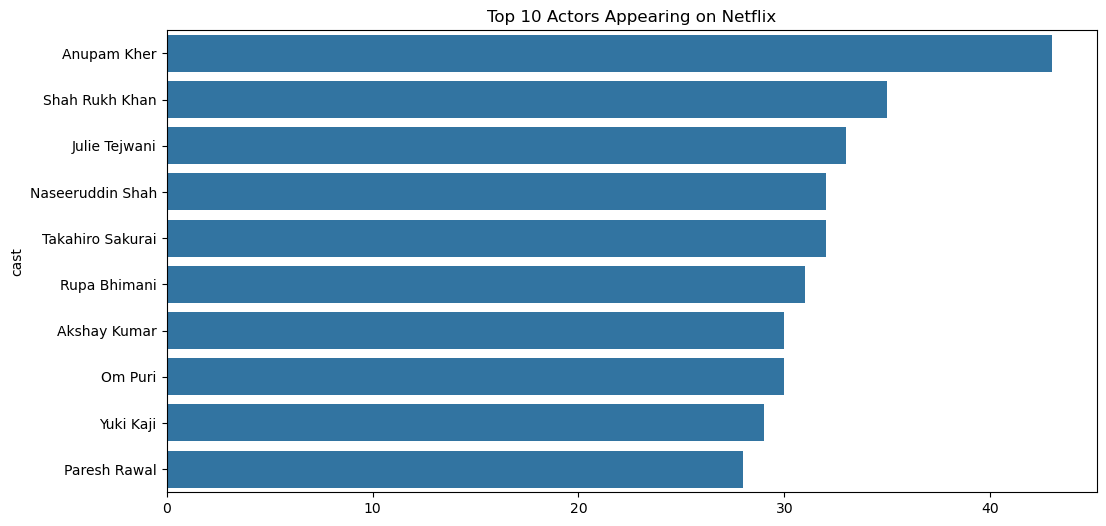

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Paresh Rawal        28
Name: count, dtype: int64

In [22]:
# Top 10 Actors
cast_df = (
    df[df["cast"] != "Unknown"]["cast"]
    .str.split(", ")
    .explode()
)
top_cast = cast_df.value_counts().head(10)

top_cast
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_cast.values,
    y=top_cast.index
)

plt.title("Top 10 Actors Appearing on Netflix")
plt.show()
top_cast

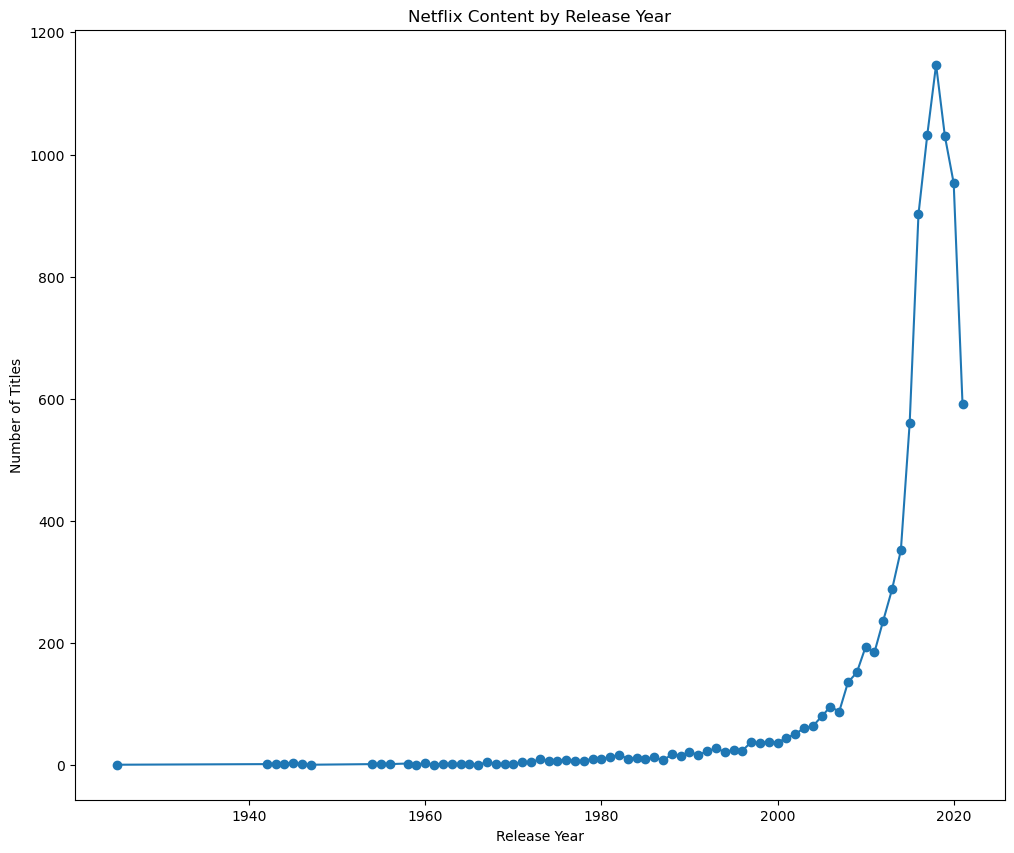

In [21]:
#Relese year analysis
release_count = (
    df["release_year"]
    .value_counts()
    .sort_index()
)
plt.figure(figsize=(12,10))

plt.plot(
    release_count.index,
    release_count.values,
    marker="o"
    
)
plt.title("Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

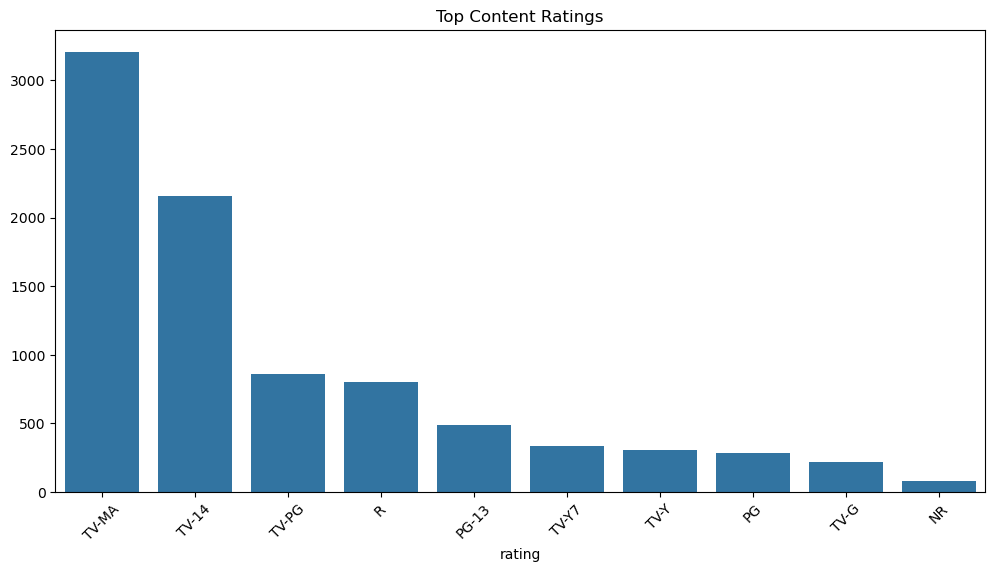

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

In [72]:
#Content Rating Analysis
rating_count = df["rating"].value_counts().head(10)
plt.figure(figsize=(12, 6))

sns.barplot(
    x=rating_count.index,
    y=rating_count.values
)

plt.xticks(rotation=45)

plt.title("Top Content Ratings")

plt.show()

rating_count

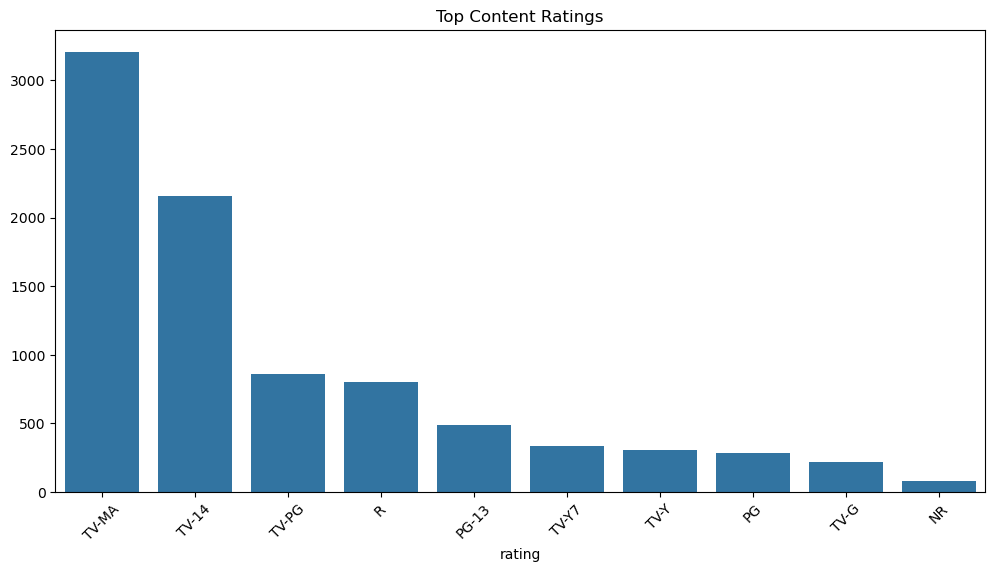

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

In [8]:
#Content Rating Analysis
rating_count = df["rating"].value_counts().head(10)

rating_count

plt.figure(figsize=(12, 6))

sns.barplot(
    x=rating_count.index,
    y=rating_count.values
)

plt.xticks(rotation=45)

plt.title("Top Content Ratings")

plt.show()
rating_count

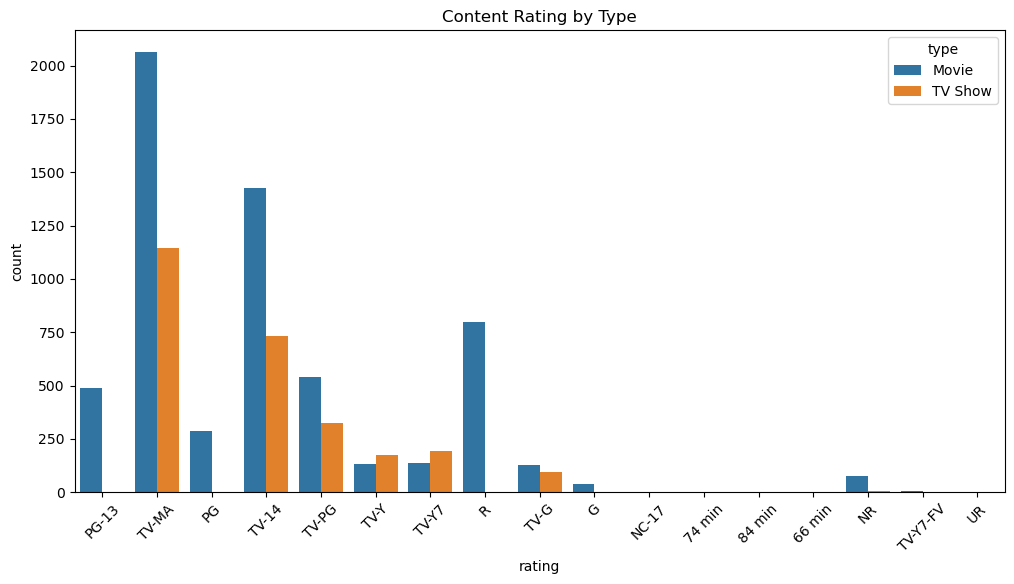

In [9]:
#Movies vs TV Shows by Rating
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="rating",
    hue="type"
)

plt.xticks(rotation=45)

plt.title("Content Rating by Type")

plt.show()

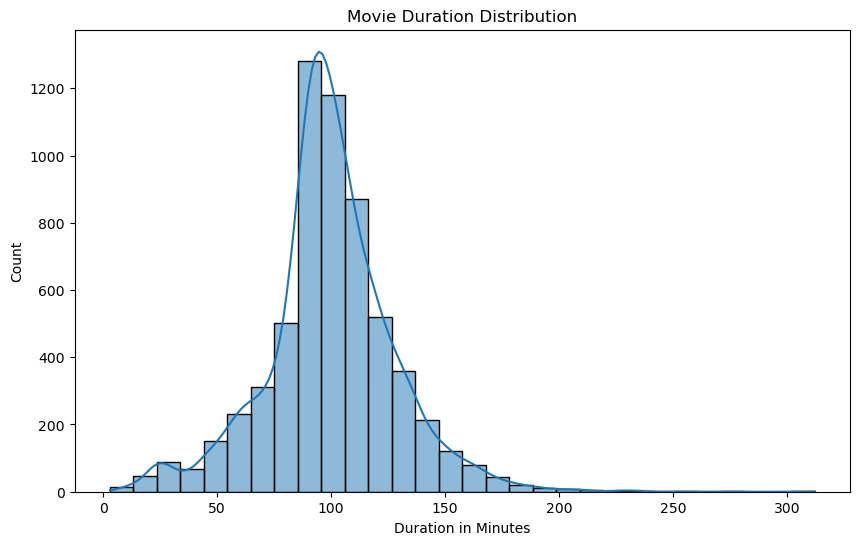

In [11]:
#Duration Analysis for Movies
movies = df[df["type"] == "Movie"].copy()
movies["duration_min"] = (
    movies["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)
movies["duration_min"].describe()
plt.figure(figsize=(10, 6))

sns.histplot(
    movies["duration_min"],
    bins=30,
    kde=True
)

plt.title("Movie Duration Distribution")
plt.xlabel("Duration in Minutes")

plt.show()

In [13]:
#Find Recent Content
df.sort_values(
    "release_year",
)[["title", "type", "release_year"]].head(20)

,title,type,release_year
4250,Pioneers: First Women Filmmakers*,TV Show,1925
7790,Prelude to War,Movie,1942
8205,The Battle of Midway,Movie,1942
8660,Undercover: How to Operate Behind Enemy Lines,Movie,1943
8739,Why We Fight: The Battle of Russia,Movie,1943
8763,WWII: Report from the Aleutians,Movie,1943
8640,Tunisian Victory,Movie,1944
8436,The Negro Soldier,Movie,1944
8419,The Memphis Belle: A Story of a\nFlying Fortress,Movie,1944
7930,San Pietro,Movie,1945


In [14]:
#Oldest Content
df.sort_values(
    "release_year",
)[["title", "type", "release_year"]].head(20)

,title,type,release_year
4250,Pioneers: First Women Filmmakers*,TV Show,1925
7790,Prelude to War,Movie,1942
8205,The Battle of Midway,Movie,1942
8660,Undercover: How to Operate Behind Enemy Lines,Movie,1943
8739,Why We Fight: The Battle of Russia,Movie,1943
8763,WWII: Report from the Aleutians,Movie,1943
8640,Tunisian Victory,Movie,1944
8436,The Negro Soldier,Movie,1944
8419,The Memphis Belle: A Story of a\nFlying Fortress,Movie,1944
7930,San Pietro,Movie,1945
